# Outfit Classifier Training Notebook

This notebook fits the prepared outfit dataset into a multi-label classifier workflow. It creates a leakage-safe train/validation/test split, compares three model families at 384x384, then trains the winning family at 512x512 as the main inference model.

## Imports And Config

In [15]:
import gc
import math
import json
import os
import random
import re
import shutil
import time
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("NO_ALBUMENTATIONS_UPDATE", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image, ImageOps
from sklearn.metrics import f1_score, hamming_loss, precision_score, recall_score
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

CONFIG = {
    "dataset_dir": "dataset",
    "dataset_csv": "dataset/dataset.csv",
    "checkpoints_dir": "checkpoints",
    "results_dir": "results",

    "compare_image_size": 384,
    "final_image_size": 512,
    "val_size": 0.15,
    "test_size": 0.15,
    "seed": 42,

    "comparison_epochs_384": 5,
    "winner_epochs_384": 15,
    "epochs_512": 10,
    "baseline_epochs_384": 5,
    "run_frozen_baseline": True,

    "batch_size_384": 4,
    "batch_size_512": 4,
    "early_stopping_patience": 6,
    "head_only_epochs_384": 1,
    "head_only_epochs_512": 2,
    "grad_accum_steps_384": 4,
    "grad_accum_steps_512": 4,
    "monitor_metric": "macro_f1",
    "threshold": 0.5,
    "tune_thresholds": True,
    "threshold_candidates": [0.1, 0.9, 81],
    "use_tta_eval": True,

    "device": "cuda",
    "cache_images_in_ram": True,
    "num_workers": 0,
    "pretrained": True,
    "use_weighted_sampler": True,
    "sampler_power": 0.5,

    "lr_backbone": 1e-5,
    "lr_head": 1e-3,
    "weight_decay": 5e-5,
    "pos_weight_cap": 6.0,
    "loss_name": "focal_bce",
    "focal_gamma": 2.0,
    "lr_schedule": "cosine",
    "min_lr_factor": 0.1,
}

MODEL_FAMILIES = {
    "convnext_base_384": {
        "family": "convnext",
        "timm_name": "convnext_base.fb_in22k_ft_in1k_384",
    },
    "swin_base_384": {
        "family": "swin_transformer",
        "timm_name": "swin_base_patch4_window12_384.ms_in22k_ft_in1k",
    },
    "maxvit_small_384": {
        "family": "maxvit",
        "timm_name": "maxvit_small_tf_384.in1k",
    }
}

Path(CONFIG["checkpoints_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["results_dir"]).mkdir(parents=True, exist_ok=True)


## Runtime Setup

In [2]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device(config):
    if config["device"] == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def clear_memory(device):
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()


def report_cuda_memory(label=""):
    if device.type != "cuda":
        return
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    free = total - reserved
    print(f"CUDA memory {label}: allocated={allocated:.2f} GB | reserved={reserved:.2f} GB | approx free={free:.2f} GB | total={total:.2f} GB")


seed_everything(CONFIG["seed"])
device = get_device(CONFIG)
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))
    report_cuda_memory("after setup")


Using device: cuda
NVIDIA GeForce RTX 4060
CUDA memory after setup: allocated=0.00 GB | reserved=0.00 GB | approx free=7.62 GB | total=7.62 GB


## Leakage-Safe Dataset Split

The prepared CSV already contains augmented rows. Splitting rows directly is flawed because an original image can land in train while its augmented duplicate lands in validation or test. This split groups every augmented variant with its original. Train keeps augmented variants; validation and test use original images only.

In [3]:
AUG_SUFFIX_RE = re.compile(r"_(aug_[A-Za-z0-9]+)$")


def base_filename(filename):
    path = Path(filename)
    stem = AUG_SUFFIX_RE.sub("", path.stem)
    return f"{stem}{path.suffix.lower()}"


def is_augmented_filename(filename):
    return bool(AUG_SUFFIX_RE.search(Path(filename).stem))


def image_dir_for_size(size):
    return Path(CONFIG["dataset_dir"]) / f"train_{size}"


def load_prepared_rows(config):
    df = pd.read_csv(config["dataset_csv"])
    if "filename" not in df.columns:
        raise ValueError("dataset.csv must contain a filename column.")
    ignored = {"filename", "split"}
    class_names = [c for c in df.columns if c not in ignored]
    if not class_names:
        raise ValueError("No label columns found in dataset.csv.")

    df = df[["filename"] + class_names].copy()
    df["base_id"] = df["filename"].map(base_filename)
    df["is_augmented"] = df["filename"].map(is_augmented_filename)

    availability = {}
    for size in [config["compare_image_size"], config["final_image_size"]]:
        image_dir = image_dir_for_size(size)
        exists_col = f"exists_{size}"
        df[exists_col] = df["filename"].map(lambda name: (image_dir / name).is_file())
        missing = df.loc[~df[exists_col], "filename"].tolist()
        availability[size] = {"image_dir": str(image_dir), "missing_rows": len(missing)}
        if missing:
            path = Path(config["results_dir"]) / f"missing_rows_{size}.txt"
            path.write_text("\n".join(missing), encoding="utf-8")
            print(f"{size}px missing prepared rows: {len(missing)} -> {path}")

    keep_cols = [f"exists_{config['compare_image_size']}", f"exists_{config['final_image_size']}"]
    before = len(df)
    df = df[df[keep_cols].all(axis=1)].copy().reset_index(drop=True)
    print(f"Prepared rows usable in both sizes: {len(df)}/{before}")
    return df, class_names, availability


def split_groups(df, class_names, config):
    try:
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
        use_iterative = True
    except ImportError:
        from sklearn.model_selection import train_test_split
        use_iterative = False

    group_df = df.groupby("base_id", as_index=False)[class_names].max()
    y = group_df[class_names].values.astype(int)
    indices = np.arange(len(group_df))

    if use_iterative:
        split_test = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=config["test_size"],
            random_state=config["seed"],
        )
        train_val_idx, test_idx = next(split_test.split(indices, y))

        val_fraction = config["val_size"] / (1.0 - config["test_size"])
        split_val = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=val_fraction,
            random_state=config["seed"] + 1,
        )
        train_rel_idx, val_rel_idx = next(split_val.split(train_val_idx, y[train_val_idx]))
        train_idx = train_val_idx[train_rel_idx]
        val_idx = train_val_idx[val_rel_idx]
    else:
        train_val_idx, test_idx = train_test_split(
            indices,
            test_size=config["test_size"],
            random_state=config["seed"],
            shuffle=True,
        )
        val_fraction = config["val_size"] / (1.0 - config["test_size"])
        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=val_fraction,
            random_state=config["seed"] + 1,
            shuffle=True,
        )
        print("iterative-stratification is unavailable; using non-stratified group split.")

    group_df["split"] = "unused"
    group_df.loc[train_idx, "split"] = "train"
    group_df.loc[val_idx, "split"] = "val"
    group_df.loc[test_idx, "split"] = "test"

    split_map = dict(zip(group_df["base_id"], group_df["split"]))
    rows = df.copy()
    rows["split"] = rows["base_id"].map(split_map)

    train_df = rows[rows["split"] == "train"].copy().reset_index(drop=True)
    val_df = rows[(rows["split"] == "val") & (~rows["is_augmented"])].copy().reset_index(drop=True)
    test_df = rows[(rows["split"] == "test") & (~rows["is_augmented"])].copy().reset_index(drop=True)

    keep_columns = ["filename"] + class_names
    split_dir = Path(config["results_dir"])
    train_df[keep_columns].to_csv(split_dir / "train_split.csv", index=False)
    val_df[keep_columns].to_csv(split_dir / "val_split.csv", index=False)
    test_df[keep_columns].to_csv(split_dir / "test_split.csv", index=False)

    summary = pd.DataFrame([
        {"split": "train", "rows": len(train_df), "original_rows": int((~train_df["is_augmented"]).sum()), "augmented_rows": int(train_df["is_augmented"].sum())},
        {"split": "val", "rows": len(val_df), "original_rows": len(val_df), "augmented_rows": 0},
        {"split": "test", "rows": len(test_df), "original_rows": len(test_df), "augmented_rows": 0},
    ])
    summary.to_csv(split_dir / "split_summary.csv", index=False)
    return train_df[keep_columns], val_df[keep_columns], test_df[keep_columns], group_df, summary


all_rows, CLASSES, availability = load_prepared_rows(CONFIG)
train_df, val_df, test_df, group_df, split_summary = split_groups(all_rows, CLASSES, CONFIG)

print(f"Classes ({len(CLASSES)}): {CLASSES}")
print(split_summary.to_string(index=False))
print("\nSmallest train class counts:")
print(train_df[CLASSES].sum().sort_values().head(10).to_string())


384px missing prepared rows: 16 -> results/missing_rows_384.txt
512px missing prepared rows: 16 -> results/missing_rows_512.txt
Prepared rows usable in both sizes: 9370/9386
Classes (24): ['dress', 't_shirt', 'shirt', 'sweater', 'hoodie', 'jacket', 'coat', 'blazer', 'cardigan', 'trousers', 'jeans', 'shorts', 'skirt', 'leggings', 'shoes', 'sneakers', 'boots', 'heels', 'sandals', 'bag', 'hat', 'scarf', 'belt', 'sunglasses']
split  rows  original_rows  augmented_rows
train  6598           2986            3612
  val   641            641               0
 test   641            641               0

Smallest train class counts:
hoodie      162
cardigan    258
scarf       258
sandals     330
coat        408
sneakers    438
sweater     501
leggings    591
belt        615
blazer      642


## Dataset And DataLoaders

In [4]:
IMAGE_RAM_CACHE = {}


def load_image_uint8(image_path):
    with Image.open(image_path) as img:
        image = ImageOps.exif_transpose(img).convert("RGB")
    array = np.asarray(image, dtype=np.uint8)
    return torch.from_numpy(array).permute(2, 0, 1).contiguous()


def get_image_cache(image_dir, filenames):
    image_dir = Path(image_dir)
    cache_key = str(image_dir.resolve())
    cache = IMAGE_RAM_CACHE.setdefault(cache_key, {})
    missing = [name for name in pd.unique(filenames) if name not in cache]

    if missing:
        before = len(cache)
        for name in tqdm(missing, desc=f"Caching {image_dir.name}"):
            cache[name] = load_image_uint8(image_dir / name)
        cached = len(cache) - before
        total_mb = sum(t.numel() for t in cache.values()) / 1024**2
        print(f"Cached {cached} new images for {image_dir} | total={len(cache)} images | approx uint8 RAM={total_mb:.1f} MB")
    else:
        total_mb = sum(t.numel() for t in cache.values()) / 1024**2
        print(f"Reusing RAM cache for {image_dir} | total={len(cache)} images | approx uint8 RAM={total_mb:.1f} MB")

    return cache


class OutfitDataset(Dataset):
    def __init__(self, df, image_dir, class_names, mean, std, training=False, cache_images=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.class_names = list(class_names)
        self.cache_images = bool(cache_images)
        self.image_cache = get_image_cache(self.image_dir, self.df["filename"]) if self.cache_images else None

        tensor_transforms = []
        if training:
            tensor_transforms.extend([
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(degrees=10),
                T.RandomPerspective(distortion_scale=0.1, p=0.3),
                T.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
            ])
        tensor_transforms.append(T.ConvertImageDtype(torch.float32))
        if training:
            tensor_transforms.append(T.RandomErasing(p=0.3, scale=(0.02, 0.15), value=0.0))
        tensor_transforms.append(T.Normalize(mean=mean, std=std))
        self.tensor_transform = T.Compose(tensor_transforms)

        pil_transforms = []
        if training:
            pil_transforms.extend([
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(degrees=10),
                T.RandomPerspective(distortion_scale=0.1, p=0.3),
                T.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
            ])
        pil_transforms.append(T.ToTensor())
        if training:
            pil_transforms.append(T.RandomErasing(p=0.3, scale=(0.02, 0.15), value=0.0))
        pil_transforms.append(T.Normalize(mean=mean, std=std))
        self.pil_transform = T.Compose(pil_transforms)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["filename"]
        if self.cache_images:
            image = self.image_cache[filename]
            image = self.tensor_transform(image)
        else:
            image_path = self.image_dir / filename
            with Image.open(image_path) as img:
                image = ImageOps.exif_transpose(img).convert("RGB")
            image = self.pil_transform(image)

        labels = torch.tensor(row[self.class_names].values.astype(np.float32))
        return image, labels


def clear_image_ram_cache(image_size=None):
    if image_size is None:
        IMAGE_RAM_CACHE.clear()
        print("Cleared all image RAM caches.")
        return

    image_dir = image_dir_for_size(image_size).resolve()
    removed = IMAGE_RAM_CACHE.pop(str(image_dir), None)
    if removed is None:
        print(f"No RAM cache found for {image_dir}.")
    else:
        print(f"Cleared RAM cache for {image_dir} ({len(removed)} images).")


def model_normalization(timm_name):
    model = timm.create_model(timm_name, pretrained=False, num_classes=0)
    cfg = timm.data.resolve_model_data_config(model)
    del model
    return tuple(cfg["mean"]), tuple(cfg["std"])


def make_sample_weights(df, class_names, power):
    labels = df[class_names].values.astype(np.float32)
    counts = labels.sum(axis=0)
    inv_freq = 1.0 / np.clip(counts, 1.0, None)
    positive_counts = np.clip(labels.sum(axis=1), 1.0, None)
    weights = (labels * inv_freq).sum(axis=1) / positive_counts
    weights = np.power(np.clip(weights, 1e-8, None), power)
    return torch.as_tensor(weights / weights.mean(), dtype=torch.double)


def make_loader_kwargs(config, batch_size):
    num_workers = int(config.get("num_workers", 0))
    if config.get("cache_images_in_ram", False) and num_workers > 0:
        print("cache_images_in_ram=True, forcing DataLoader num_workers=0 to avoid duplicated worker caches.")
        num_workers = 0

    kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "pin_memory": device.type == "cuda",
    }
    if num_workers > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return kwargs


def make_dataloaders(image_size, timm_name, batch_size, config):
    image_dir = image_dir_for_size(image_size)
    mean, std = model_normalization(timm_name)
    cache_images = config.get("cache_images_in_ram", False)

    datasets = {
        "train": OutfitDataset(train_df, image_dir, CLASSES, mean, std, training=True, cache_images=cache_images),
        "val": OutfitDataset(val_df, image_dir, CLASSES, mean, std, training=False, cache_images=cache_images),
        "test": OutfitDataset(test_df, image_dir, CLASSES, mean, std, training=False, cache_images=cache_images),
    }

    sampler = None
    if config["use_weighted_sampler"]:
        sample_weights = make_sample_weights(train_df, CLASSES, config["sampler_power"])
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
            generator=torch.Generator().manual_seed(config["seed"]),
        )
        print(
            "Weighted sampler enabled | "
            f"min={sample_weights.min():.3f}, median={sample_weights.median():.3f}, max={sample_weights.max():.3f}"
        )

    kwargs = make_loader_kwargs(config, batch_size)
    loaders = {
        "train": DataLoader(datasets["train"], shuffle=sampler is None, sampler=sampler, **kwargs),
        "val": DataLoader(datasets["val"], shuffle=False, **kwargs),
        "test": DataLoader(datasets["test"], shuffle=False, **kwargs),
    }
    return loaders, mean, std


## Model Definition

In [5]:
class TimmMultiLabelModel(nn.Module):
    def __init__(self, timm_name, num_classes, pretrained=True, image_size=None):
        super().__init__()
        self.timm_name = timm_name
        create_kwargs = {"pretrained": pretrained, "num_classes": 0}
        if image_size is not None:
            create_kwargs["img_size"] = int(image_size)
        try:
            self.backbone = timm.create_model(timm_name, **create_kwargs)
        except TypeError:
            # ConvNeXt does not accept img_size, but it is convolutional and can run at 512px.
            create_kwargs.pop("img_size", None)
            self.backbone = timm.create_model(timm_name, **create_kwargs)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))

    def forward(self, x):
        features = self.backbone(x)
        if features.ndim > 2:
            features = torch.flatten(torch.nn.functional.adaptive_avg_pool2d(features, 1), 1)
        return self.head(features)


def build_model(model_info, num_classes, config, image_size=None):
    return TimmMultiLabelModel(
        model_info["timm_name"],
        num_classes,
        pretrained=config["pretrained"],
        image_size=image_size,
    )


## Training And Evaluation Helpers

In [6]:
class FocalBCELoss(nn.Module):
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.gamma = float(gamma)
        self.register_buffer("pos_weight", pos_weight)

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction="none",
        )
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1.0 - targets) * (1.0 - probs)
        return ((1.0 - pt).pow(self.gamma) * bce).mean()


def build_criterion(df, class_names, config):
    labels = df[class_names].values.astype(np.float32)
    positives = labels.sum(axis=0)
    negatives = len(labels) - positives
    pos_weight = negatives / np.clip(positives, 1.0, None)
    pos_weight = np.clip(pos_weight, 1.0, config["pos_weight_cap"])
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32, device=device)

    if config.get("loss_name", "bce") == "focal_bce":
        return FocalBCELoss(pos_weight=pos_weight, gamma=config.get("focal_gamma", 2.0))
    if config.get("loss_name", "bce") == "bce":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    raise ValueError(f"Unsupported loss_name: {config['loss_name']}")


def collect_outputs(model, loader, criterion=None, use_tta=False):
    model.eval()
    probs, targets = [], []
    running_loss = 0.0
    total = 0
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device, non_blocking=True)
            labels_device = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
                if use_tta:
                    logits = (logits + model(TF.hflip(images))) / 2.0
                if criterion is not None:
                    loss = criterion(logits, labels_device)
                    running_loss += loss.item() * images.size(0)
                    total += images.size(0)
            probs.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(labels.numpy().astype(int))
    mean_loss = running_loss / max(total, 1) if criterion is not None else np.nan
    return np.vstack(probs), np.vstack(targets), mean_loss


def threshold_vector(threshold, class_names):
    if isinstance(threshold, dict):
        return np.array([float(threshold[name]) for name in class_names], dtype=np.float32)
    values = np.asarray(threshold, dtype=np.float32)
    if values.ndim == 0:
        return float(values)
    if len(values) != len(class_names):
        raise ValueError(f"Expected {len(class_names)} thresholds, got {len(values)}")
    return values


def find_optimal_thresholds(probs, targets, class_names, config):
    start, stop, count = config.get("threshold_candidates", [0.1, 0.9, 81])
    candidates = np.linspace(float(start), float(stop), int(count))
    thresholds = {}
    for i, name in enumerate(class_names):
        scores = [
            f1_score(targets[:, i], probs[:, i] >= t, zero_division=0)
            for t in candidates
        ]
        thresholds[name] = float(candidates[int(np.argmax(scores))])
    return thresholds


def metrics_from_probs(probs, targets, threshold, class_names, loss=np.nan):
    thresholds = threshold_vector(threshold, class_names)
    preds = (probs >= thresholds).astype(int)
    per_class = f1_score(targets, preds, average=None, zero_division=0)
    return {
        "loss": loss,
        "micro_f1": f1_score(targets, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(targets, preds, average="macro", zero_division=0),
        "samples_f1": f1_score(targets, preds, average="samples", zero_division=0),
        "precision_micro": precision_score(targets, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(targets, preds, average="micro", zero_division=0),
        "hamming_loss": hamming_loss(targets, preds),
        "per_class_f1": dict(zip(class_names, per_class)),
        "preds": preds,
        "targets": targets,
        "probs": probs,
    }


def evaluate(model, loader, threshold, class_names, criterion=None, use_tta=False):
    probs, targets, loss = collect_outputs(model, loader, criterion, use_tta=use_tta)
    return metrics_from_probs(probs, targets, threshold, class_names, loss)


def measure_inference_time(model, loader, n_runs=50, use_tta=False):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:1].to(device, non_blocking=True)
    with torch.no_grad():
        for _ in range(10):
            logits = model(images)
            if use_tta:
                logits = (logits + model(TF.hflip(images))) / 2.0
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(n_runs):
            logits = model(images)
            if use_tta:
                logits = (logits + model(TF.hflip(images))) / 2.0
        if device.type == "cuda":
            torch.cuda.synchronize()
    return (time.perf_counter() - start) * 1000.0 / n_runs


## Train One Model

In [7]:
def set_backbone_trainable(model, trainable):
    for param in model.backbone.parameters():
        param.requires_grad = trainable
    for param in model.head.parameters():
        param.requires_grad = True


def make_optimizer(model, config, backbone_trainable):
    if backbone_trainable:
        param_groups = [
            {"params": model.backbone.parameters(), "lr": config["lr_backbone"]},
            {"params": model.head.parameters(), "lr": config["lr_head"]},
        ]
    else:
        param_groups = [{"params": model.head.parameters(), "lr": config["lr_head"]}]
    return optim.AdamW(param_groups, weight_decay=config["weight_decay"])


def make_scheduler(optimizer, config, epochs, steps_per_epoch):
    if config.get("lr_schedule", "none") == "none":
        return None
    if config["lr_schedule"] != "cosine":
        raise ValueError(f"Unsupported lr_schedule: {config['lr_schedule']}")

    total_steps = max(1, int(epochs) * max(1, int(steps_per_epoch)))
    min_lr_factor = float(config.get("min_lr_factor", 0.1))

    def lr_lambda(step):
        progress = min(step, total_steps) / total_steps
        return min_lr_factor + 0.5 * (1.0 - min_lr_factor) * (1.0 + math.cos(math.pi * progress))

    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


def load_model_checkpoint(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    source_state = checkpoint["model_state_dict"]
    target_state = model.state_dict()
    compatible_state = {}
    skipped = []
    for key, value in source_state.items():
        if key in target_state and target_state[key].shape == value.shape:
            compatible_state[key] = value
        else:
            skipped.append(key)
    missing, unexpected = model.load_state_dict(compatible_state, strict=False)
    if skipped:
        print(f"Skipped {len(skipped)} checkpoint tensors with incompatible shapes, usually size-specific positional buffers.")
        print("First skipped keys:", skipped[:5])
    if unexpected:
        print("Unexpected checkpoint keys:", unexpected[:5])
    return checkpoint


def train_one_model(
    model_name,
    model_info,
    image_size,
    epochs,
    batch_size,
    config,
    initial_checkpoint=None,
    freeze_backbone_all_epochs=False,
):
    print(f"\n=== Training {model_name} at {image_size}x{image_size} ({model_info['timm_name']}) ===")
    if initial_checkpoint is not None:
        print(f"Initializing from checkpoint: {initial_checkpoint}")
    if freeze_backbone_all_epochs:
        print("Frozen-backbone baseline: only the classification head will train.")

    clear_memory(device)
    loaders, mean, std = make_dataloaders(image_size, model_info["timm_name"], batch_size, config)

    model = build_model(model_info, len(CLASSES), config, image_size=image_size).to(device)
    if initial_checkpoint is not None:
        source_checkpoint = load_model_checkpoint(model, initial_checkpoint, device)
        print(
            "Loaded source checkpoint | "
            f"source_size={source_checkpoint.get('image_size')} "
            f"source_best_epoch={source_checkpoint.get('best_epoch')} "
            f"source_best_val={source_checkpoint.get('best_val_score'):.4f}"
        )
    report_cuda_memory(f"after building {model_name}")

    criterion = build_criterion(train_df, CLASSES, config)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    use_amp = device.type == "cuda"

    head_only_epochs = config["head_only_epochs_512"] if image_size == config["final_image_size"] else config["head_only_epochs_384"]
    if freeze_backbone_all_epochs:
        head_only_epochs = epochs
    grad_accum_steps = config["grad_accum_steps_512"] if image_size == config["final_image_size"] else config["grad_accum_steps_384"]
    grad_accum_steps = max(1, int(grad_accum_steps))

    optimizer_steps_per_epoch = math.ceil(len(loaders["train"]) / grad_accum_steps)

    set_backbone_trainable(model, False)
    optimizer = make_optimizer(model, config, backbone_trainable=False)
    scheduler = make_scheduler(optimizer, config, min(head_only_epochs, epochs), optimizer_steps_per_epoch)
    current_stage = "head"

    checkpoint_path = Path(config["checkpoints_dir"]) / f"{model_name}_{image_size}_best.pth"
    best_score = -1.0
    best_epoch = 0
    no_improve = 0
    history = []

    for epoch in range(1, epochs + 1):
        stage = "head" if epoch <= head_only_epochs else "full"
        if stage != current_stage:
            set_backbone_trainable(model, True)
            optimizer = make_optimizer(model, config, backbone_trainable=True)
            scheduler = make_scheduler(optimizer, config, epochs - epoch + 1, optimizer_steps_per_epoch)
            current_stage = stage
            print(f"Unfroze backbone for full fine-tuning at epoch {epoch}.")

        model.train()
        running_loss = 0.0
        optimizer.zero_grad(set_to_none=True)
        progress = tqdm(loaders["train"], desc=f"{model_name} {stage} epoch {epoch}/{epochs}", leave=False)
        for step, (images, labels) in enumerate(progress, start=1):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                loss = criterion(model(images), labels)
                scaled_loss = loss / grad_accum_steps
            scaler.scale(scaled_loss).backward()

            if step % grad_accum_steps == 0 or step == len(loaders["train"]):
                scaler.step(optimizer)
                scaler.update()
                if scheduler is not None:
                    scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            running_loss += loss.item() * images.size(0)
            progress.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[-1]['lr']:.2e}", accum=grad_accum_steps)

        train_loss = running_loss / len(loaders["train"].dataset)
        val_metrics = evaluate(model, loaders["val"], config["threshold"], CLASSES, criterion, use_tta=False)
        score = val_metrics[config["monitor_metric"]]
        history.append({
            "epoch": epoch,
            "stage": stage,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_micro_f1": val_metrics["micro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_samples_f1": val_metrics["samples_f1"],
            "lr_head": optimizer.param_groups[-1]["lr"],
        })
        print(
            f"{model_name} epoch {epoch}: stage={stage} | "
            f"train loss={train_loss:.4f} val loss={val_metrics['loss']:.4f} | "
            f"val micro={val_metrics['micro_f1']:.4f} macro={val_metrics['macro_f1']:.4f}"
        )
        report_cuda_memory(f"after {model_name} epoch {epoch}")

        if score > best_score:
            best_score = score
            best_epoch = epoch
            no_improve = 0
            torch.save(
                {
                    "model_name": model_name,
                    "family": model_info["family"],
                    "timm_name": model_info["timm_name"],
                    "image_size": image_size,
                    "class_names": CLASSES,
                    "threshold": config["threshold"],
                    "per_class_thresholds": None,
                    "threshold_tuning_enabled": bool(config.get("tune_thresholds", False)),
                    "normalization_mean": mean,
                    "normalization_std": std,
                    "model_state_dict": model.state_dict(),
                    "best_val_score": float(best_score),
                    "best_epoch": best_epoch,
                    "monitor_metric": config["monitor_metric"],
                    "head_only_epochs": head_only_epochs,
                    "grad_accum_steps": grad_accum_steps,
                    "freeze_backbone_all_epochs": freeze_backbone_all_epochs,
                    "initial_checkpoint": str(initial_checkpoint) if initial_checkpoint is not None else None,
                    "lr_schedule": config.get("lr_schedule", "none"),
                    "config": dict(config),
                },
                checkpoint_path,
            )
        else:
            no_improve += 1
            if no_improve >= config["early_stopping_patience"]:
                print(f"Early stopping {model_name} after epoch {epoch}.")
                break

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    val_probs, val_targets, val_loss = collect_outputs(
        model,
        loaders["val"],
        criterion,
        use_tta=bool(config.get("use_tta_eval", False)),
    )
    test_probs, test_targets, test_loss = collect_outputs(
        model,
        loaders["test"],
        criterion,
        use_tta=bool(config.get("use_tta_eval", False)),
    )
    default_threshold = config["threshold"]
    val_metrics_default = metrics_from_probs(val_probs, val_targets, default_threshold, CLASSES, val_loss)
    test_metrics_default = metrics_from_probs(test_probs, test_targets, default_threshold, CLASSES, test_loss)

    per_class_thresholds = None
    if config.get("tune_thresholds", False):
        per_class_thresholds = find_optimal_thresholds(val_probs, val_targets, CLASSES, config)
        val_metrics_tuned = metrics_from_probs(val_probs, val_targets, per_class_thresholds, CLASSES, val_loss)
        test_metrics_tuned = metrics_from_probs(test_probs, test_targets, per_class_thresholds, CLASSES, test_loss)
    else:
        val_metrics_tuned = val_metrics_default
        test_metrics_tuned = test_metrics_default

    val_metrics = val_metrics_tuned if config.get("tune_thresholds", False) else val_metrics_default
    test_metrics = test_metrics_tuned if config.get("tune_thresholds", False) else test_metrics_default

    checkpoint["per_class_thresholds"] = per_class_thresholds
    checkpoint["threshold_tuning_enabled"] = bool(config.get("tune_thresholds", False))
    checkpoint["use_tta_eval"] = bool(config.get("use_tta_eval", False))
    checkpoint["val_macro_f1_default"] = float(val_metrics_default["macro_f1"])
    checkpoint["test_macro_f1_default"] = float(test_metrics_default["macro_f1"])
    checkpoint["val_macro_f1_tuned"] = float(val_metrics_tuned["macro_f1"])
    checkpoint["test_macro_f1_tuned"] = float(test_metrics_tuned["macro_f1"])
    torch.save(checkpoint, checkpoint_path)

    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    inference_ms = measure_inference_time(model, loaders["test"], use_tta=bool(config.get("use_tta_eval", False)))

    row = {
        "model": model_name,
        "family": model_info["family"],
        "timm_name": model_info["timm_name"],
        "image_size": image_size,
        "training_mode": "frozen_baseline" if freeze_backbone_all_epochs else ("finetune_from_384" if initial_checkpoint is not None else "finetune"),
        "params_M": round(params_m, 3),
        "best_epoch": checkpoint["best_epoch"],
        "best_val_score": checkpoint["best_val_score"],
        "val_loss": val_metrics["loss"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_samples_f1": val_metrics["samples_f1"],
        "val_micro_f1_default": val_metrics_default["micro_f1"],
        "val_macro_f1_default": val_metrics_default["macro_f1"],
        "val_micro_f1_tuned": val_metrics_tuned["micro_f1"],
        "val_macro_f1_tuned": val_metrics_tuned["macro_f1"],
        "test_loss": test_metrics["loss"],
        "test_micro_f1": test_metrics["micro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_samples_f1": test_metrics["samples_f1"],
        "test_micro_f1_default": test_metrics_default["micro_f1"],
        "test_macro_f1_default": test_metrics_default["macro_f1"],
        "test_micro_f1_tuned": test_metrics_tuned["micro_f1"],
        "test_macro_f1_tuned": test_metrics_tuned["macro_f1"],
        "thresholds": "per_class" if per_class_thresholds is not None else "fixed_0.5",
        "tta_eval": bool(config.get("use_tta_eval", False)),
        "test_precision_micro": test_metrics["precision_micro"],
        "test_recall_micro": test_metrics["recall_micro"],
        "test_hamming_loss": test_metrics["hamming_loss"],
        "inference_time_ms": inference_ms,
        "checkpoint": str(checkpoint_path),
        "initial_checkpoint": str(initial_checkpoint) if initial_checkpoint is not None else "",
    }

    result = {
        "row": row,
        "history": pd.DataFrame(history),
        "per_class_test_f1": test_metrics["per_class_f1"],
        "checkpoint_path": checkpoint_path,
    }
    del model, loaders, optimizer, criterion
    clear_memory(device)
    return result


## Result Saving Helpers

In [8]:
def write_markdown_table(df, path):
    display_df = df.copy()
    for column in display_df.select_dtypes(include=[np.floating]).columns:
        display_df[column] = display_df[column].map(lambda value: "" if pd.isna(value) else f"{value:.4f}")
    columns = list(display_df.columns)
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for _, row in display_df.iterrows():
        lines.append("| " + " | ".join(str(row[column]) for column in columns) + " |")
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


def save_result_artifacts(rows, histories, per_class_results, suffix):
    results_dir = Path(CONFIG["results_dir"])
    comparison = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
    comparison.to_csv(results_dir / f"comparison_{suffix}.csv", index=False)
    write_markdown_table(comparison, results_dir / f"comparison_{suffix}.md")

    fig, ax = plt.subplots(figsize=(10, 5))
    comparison.set_index("model")[["val_macro_f1_default", "val_macro_f1_tuned", "test_macro_f1_default", "test_macro_f1_tuned", "test_micro_f1_tuned"]].plot(kind="bar", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Metric value")
    ax.set_title(f"Model Metrics ({suffix})")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(results_dir / f"model_metrics_{suffix}.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model_name, history in histories.items():
        axes[0].plot(history["epoch"], history["train_loss"], marker="o", label=f"{model_name} train")
        axes[0].plot(history["epoch"], history["val_loss"], marker="o", linestyle="--", label=f"{model_name} val")
        axes[1].plot(history["epoch"], history["val_macro_f1"], marker="o", label=model_name)
    axes[0].set_title("Train And Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(alpha=0.3)
    axes[1].set_title("Validation Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(results_dir / f"training_curves_{suffix}.png", dpi=180, bbox_inches="tight")
    plt.show()

    heatmap_df = pd.DataFrame(per_class_results).T[CLASSES]
    heatmap_df.to_csv(results_dir / f"per_class_f1_{suffix}.csv")
    print(f"Lowest per-class test F1 ({suffix}):")
    display(heatmap_df.mean(axis=0).sort_values().head(8).to_frame("mean_test_f1"))

    fig, ax = plt.subplots(figsize=(max(12, len(CLASSES) * 0.55), max(4, len(heatmap_df) * 0.6)))
    sns.heatmap(heatmap_df, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f", ax=ax)
    ax.set_title(f"Per-Class Test F1 ({suffix})")
    ax.set_xlabel("Class")
    ax.set_ylabel("Model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(results_dir / f"per_class_f1_{suffix}.png", dpi=180, bbox_inches="tight")
    plt.show()
    return comparison


def save_dataset_summary():
    summary = {
        "classes": CLASSES,
        "num_classes": len(CLASSES),
        "availability": availability,
        "split_summary": split_summary.to_dict(orient="records"),
        "models": MODEL_FAMILIES,
        "config": CONFIG,
    }
    Path(CONFIG["results_dir"], "dataset_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")


save_dataset_summary()


## Smoke Test

In [9]:
preview_model = next(iter(MODEL_FAMILIES.values()))
preview_loaders, _, _ = make_dataloaders(
    CONFIG["compare_image_size"],
    preview_model["timm_name"],
    CONFIG["batch_size_384"],
    CONFIG,
)
images, labels = next(iter(preview_loaders["train"]))
model = build_model(preview_model, len(CLASSES), {**CONFIG, "pretrained": False}).to(device)
with torch.no_grad():
    logits = model(images[:2].to(device))
print(f"Batch images: {tuple(images.shape)} | labels: {tuple(labels.shape)} | logits: {tuple(logits.shape)}")
del model, preview_loaders, images, labels, logits
clear_memory(device)


Caching train_384:   0%|          | 0/6598 [00:00<?, ?it/s]

Cached 6598 new images for dataset/train_384 | total=6598 images | approx uint8 RAM=2783.5 MB


Caching train_384:   0%|          | 0/641 [00:00<?, ?it/s]

Cached 641 new images for dataset/train_384 | total=7239 images | approx uint8 RAM=3054.0 MB


Caching train_384:   0%|          | 0/641 [00:00<?, ?it/s]

Cached 641 new images for dataset/train_384 | total=7880 images | approx uint8 RAM=3324.4 MB
Weighted sampler enabled | min=0.003, median=0.974, max=2.178
Batch images: (4, 3, 384, 384) | labels: (4, 24) | logits: (2, 24)


## Compare Three Model Families At 384x384

In [ ]:
comparison_rows = []
histories = {}
per_class_results = {}

for model_name, model_info in tqdm(MODEL_FAMILIES.items(), desc="Quick 384px model comparison"):
    result = train_one_model(
        model_name=f"{model_name}_quick",
        model_info=model_info,
        image_size=CONFIG["compare_image_size"],
        epochs=CONFIG["comparison_epochs_384"],
        batch_size=CONFIG["batch_size_384"],
        config=CONFIG,
    )
    comparison_rows.append(result["row"])
    histories[result["row"]["model"]] = result["history"]
    per_class_results[result["row"]["model"]] = result["per_class_test_f1"]

comparison_384_quick = save_result_artifacts(comparison_rows, histories, per_class_results, "384_quick")
comparison_384_quick


## Train Best Family At 512x512

In [14]:
best_base_model_name = "swin_base_384"
best_model_info = MODEL_FAMILIES[best_base_model_name]
quick_checkpoint = Path("checkpoints/swin_base_384_quick_384_best.pth")

print(f"Selected 384px family: {best_base_model_name}")

final_rows = []
final_histories = {}
final_per_class_results = {}

winner_384_result = train_one_model(
    model_name=f"{best_base_model_name}_winner384",
    model_info=best_model_info,
    image_size=CONFIG["compare_image_size"],
    epochs=CONFIG["winner_epochs_384"],
    batch_size=CONFIG["batch_size_384"],
    config=CONFIG,
    initial_checkpoint=quick_checkpoint if quick_checkpoint.is_file() else None,
)

final_rows.append(winner_384_result["row"])
final_histories[winner_384_result["row"]["model"]] = winner_384_result["history"]
final_per_class_results[winner_384_result["row"]["model"]] = winner_384_result["per_class_test_f1"]

if CONFIG.get("run_frozen_baseline", True):
    baseline_result = train_one_model(
        model_name=f"{best_base_model_name}_frozen_baseline",
        model_info=best_model_info,
        image_size=CONFIG["compare_image_size"],
        epochs=CONFIG["baseline_epochs_384"],
        batch_size=CONFIG["batch_size_384"],
        config=CONFIG,
        freeze_backbone_all_epochs=True,
    )
    final_rows.append(baseline_result["row"])
    final_histories[baseline_result["row"]["model"]] = baseline_result["history"]
    final_per_class_results[baseline_result["row"]["model"]] = baseline_result["per_class_test_f1"]


Selected 384px family: swin_base_384

=== Training swin_base_384_winner384 at 384x384 (swin_base_patch4_window12_384.ms_in22k_ft_in1k) ===
Initializing from checkpoint: checkpoints/swin_base_384_quick_384_best.pth
Reusing RAM cache for dataset/train_384 | total=7880 images | approx uint8 RAM=3324.4 MB
Reusing RAM cache for dataset/train_384 | total=7880 images | approx uint8 RAM=3324.4 MB
Reusing RAM cache for dataset/train_384 | total=7880 images | approx uint8 RAM=3324.4 MB
Weighted sampler enabled | min=0.003, median=0.974, max=2.178
Loaded source checkpoint | source_size=384 source_best_epoch=5 source_best_val=0.6448
CUDA memory after building swin_base_384_winner384: allocated=0.68 GB | reserved=0.70 GB | approx free=6.92 GB | total=7.62 GB


swin_base_384_winner384 head epoch 1/15:   0%|          | 0/1650 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

swin_base_384_winner384 epoch 1: stage=head | train loss=0.0760 val loss=0.1254 | val micro=0.6792 macro=0.6415
CUDA memory after swin_base_384_winner384 epoch 1: allocated=0.69 GB | reserved=1.04 GB | approx free=6.58 GB | total=7.62 GB
Unfroze backbone for full fine-tuning at epoch 2.


swin_base_384_winner384 full epoch 2/15:   0%|          | 0/1650 [00:00<?, ?it/s]

...

swin_base_384_frozen_baseline head epoch 5/5:   0%|          | 0/1650 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

swin_base_384_frozen_baseline epoch 5: stage=head | train loss=0.1311 val loss=0.1277 | val micro=0.5908 macro=0.5509
CUDA memory after swin_base_384_frozen_baseline epoch 5: allocated=0.36 GB | reserved=0.71 GB | approx free=6.91 GB | total=7.62 GB


Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

In [16]:
final_512_result = train_one_model(
    model_name=f"{best_base_model_name}_final512",
    model_info=best_model_info,
    image_size=CONFIG["final_image_size"],
    epochs=CONFIG["epochs_512"],
    batch_size=CONFIG["batch_size_512"],
    config=CONFIG,
    initial_checkpoint=winner_384_result["checkpoint_path"],
)
final_rows.append(final_512_result["row"])
final_histories[final_512_result["row"]["model"]] = final_512_result["history"]
final_per_class_results[final_512_result["row"]["model"]] = final_512_result["per_class_test_f1"]


=== Training swin_base_384_final512 at 512x512 (swin_base_patch4_window12_384.ms_in22k_ft_in1k) ===
Initializing from checkpoint: checkpoints/swin_base_384_winner384_384_best.pth


Caching train_512:   0%|          | 0/6598 [00:00<?, ?it/s]

Cached 6598 new images for dataset/train_512 | total=6598 images | approx uint8 RAM=4948.5 MB


Caching train_512:   0%|          | 0/641 [00:00<?, ?it/s]

Cached 641 new images for dataset/train_512 | total=7239 images | approx uint8 RAM=5429.2 MB


...

swin_base_384_final512 full epoch 10/10:   0%|          | 0/1650 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

swin_base_384_final512 epoch 10: stage=full | train loss=0.0180 val loss=0.2794 | val micro=0.7093 macro=0.6573
CUDA memory after swin_base_384_final512 epoch 10: allocated=1.36 GB | reserved=6.64 GB | approx free=0.98 GB | total=7.62 GB


Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/161 [00:00<?, ?it/s]

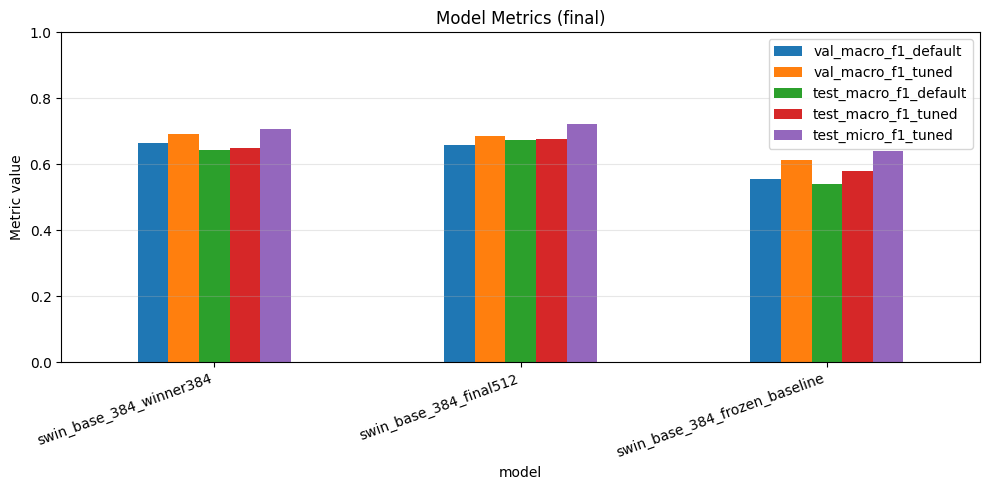

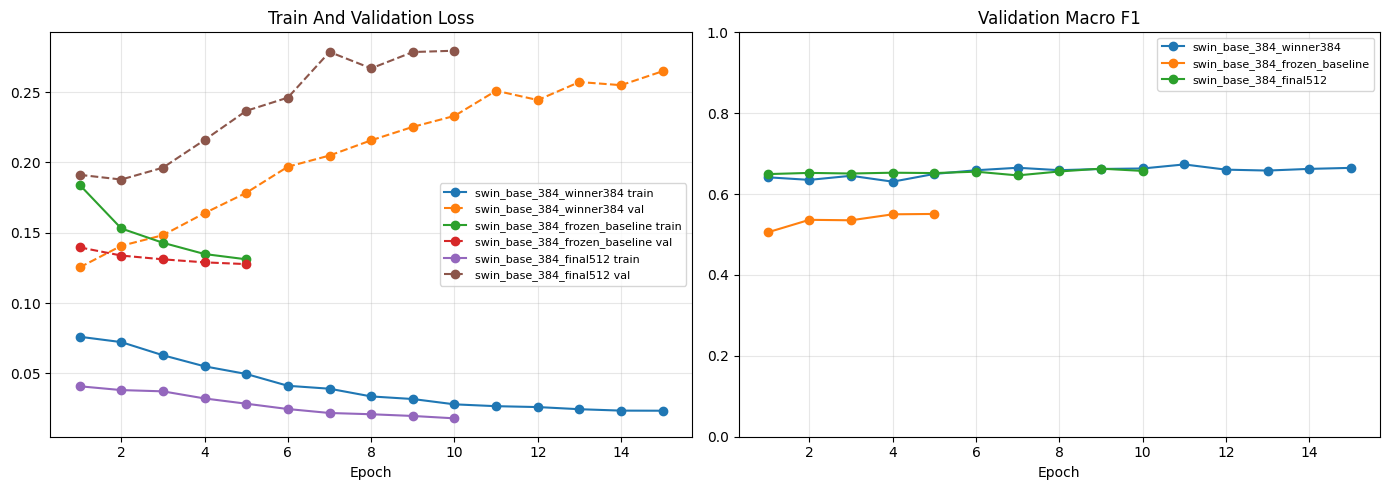

Lowest per-class test F1 (final):


,mean_test_f1
sandals,0.239831
cardigan,0.294112
scarf,0.434592
belt,0.461155
sweater,0.485177
hoodie,0.546653
shoes,0.550893
t_shirt,0.600082


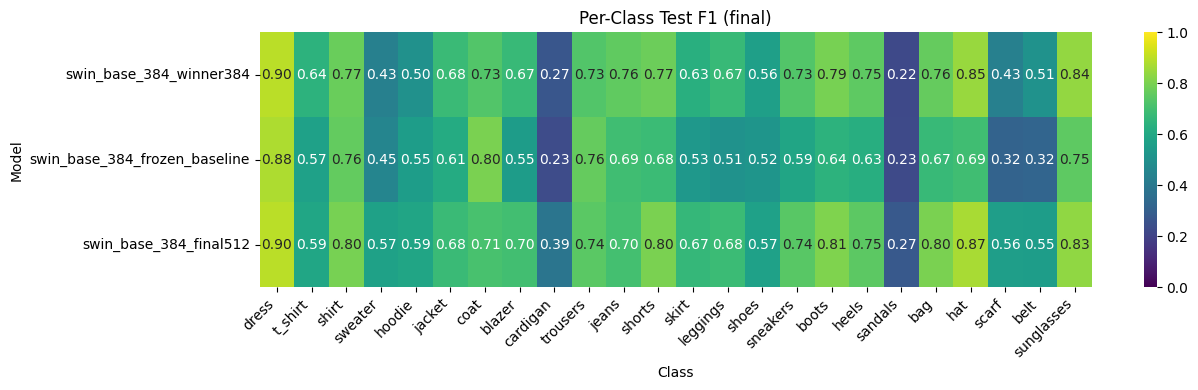

Main inference checkpoint saved to checkpoints/best_model.pth


,model,family,timm_name,image_size,training_mode,params_M,best_epoch,best_val_score,val_loss,val_micro_f1,...,test_micro_f1_tuned,test_macro_f1_tuned,thresholds,tta_eval,test_precision_micro,test_recall_micro,test_hamming_loss,inference_time_ms,checkpoint,initial_checkpoint
0,swin_base_384_winner384,swin_transformer,swin_base_patch4_window12_384.ms_in22k_ft_in1k,384,finetune_from_384,86.903,11,0.673347,0.250411,0.724158,...,0.708162,0.649478,per_class,True,0.681356,0.737164,0.064613,45.665837,checkpoints/swin_base_384_winner384_384_best.pth,checkpoints/swin_base_384_quick_384_best.pth
1,swin_base_384_final512,swin_transformer,swin_base_patch4_window12_384.ms_in22k_ft_in1k,512,finetune_from_384,86.903,9,0.662928,0.278875,0.724391,...,0.722206,0.677273,per_class,True,0.701209,0.744499,0.060907,89.606880,checkpoints/swin_base_384_final512_512_best.pth,checkpoints/swin_base_384_winner384_384_best.pth
2,swin_base_384_frozen_baseline,swin_transformer,swin_base_patch4_window12_384.ms_in22k_ft_in1k,384,frozen_baseline,86.903,5,0.550918,0.127487,0.649453,...,0.641350,0.580845,per_class,True,0.594059,0.696822,0.082878,46.033337,checkpoints/swin_base_384_frozen_baseline_384_...,


In [17]:
comparison_final = save_result_artifacts(final_rows, final_histories, final_per_class_results, "final")
main_checkpoint = Path(CONFIG["checkpoints_dir"]) / "best_model.pth"
shutil.copy2(final_512_result["checkpoint_path"], main_checkpoint)
comparison_final.to_csv(Path(CONFIG["results_dir"]) / "main_model.csv", index=False)
print(f"Main inference checkpoint saved to {main_checkpoint}")
comparison_final

## Saved Artifacts

In [18]:
print("Checkpoints:")
for path in sorted(Path(CONFIG["checkpoints_dir"]).glob("*.pth")):
    print("-", path)

print("\nResults:")
for path in sorted(Path(CONFIG["results_dir"]).glob("*")):
    print("-", path)


Checkpoints:
- checkpoints/best_model.pth
- checkpoints/convnext_base_384_384_best.pth
- checkpoints/convnext_base_384_final512_512_best.pth
- checkpoints/convnext_base_384_frozen_baseline_384_best.pth
- checkpoints/convnext_base_384_quick_384_best.pth
- checkpoints/convnext_base_384_winner384_384_best.pth
- checkpoints/maxvit_small_384_quick_384_best.pth
- checkpoints/maxvit_tiny_384_quick_384_best.pth
- checkpoints/swin_base_384_final512_512_best.pth
- checkpoints/swin_base_384_frozen_baseline_384_best.pth
- checkpoints/swin_base_384_quick_384_best.pth
- checkpoints/swin_base_384_winner384_384_best.pth

Results:
- results/comparison_384_quick.csv
- results/comparison_384_quick.md
- results/comparison_final.csv
- results/comparison_final.md
- results/dataset_summary.json
- results/inference_test_comparison.csv
- results/inference_test_per_class_f1.csv
- results/inference_test_per_class_f1.png
- results/main_model.csv
- results/missing_rows_384.txt
- results/missing_rows_512.txt
- resu